# AIT plots for Bea's talk

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
from astropy.coordinates import SkyCoord
%run pylib/skymaps
plt.style.use('dark_background')
df = pd.read_csv('files/basic_4FGL_DR4.csv', index_col=0)

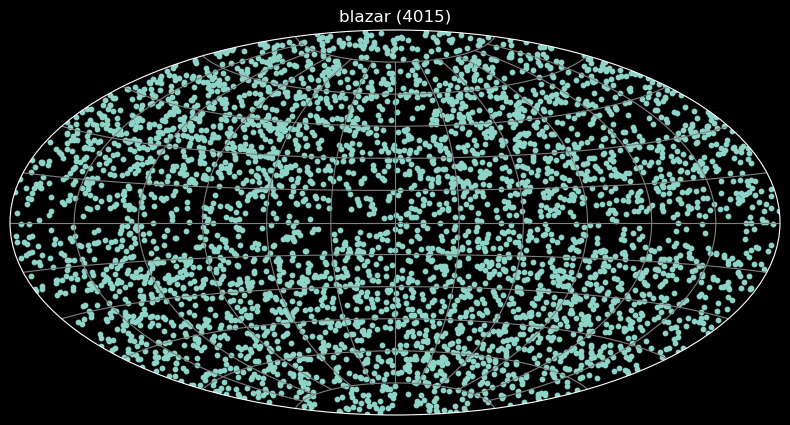

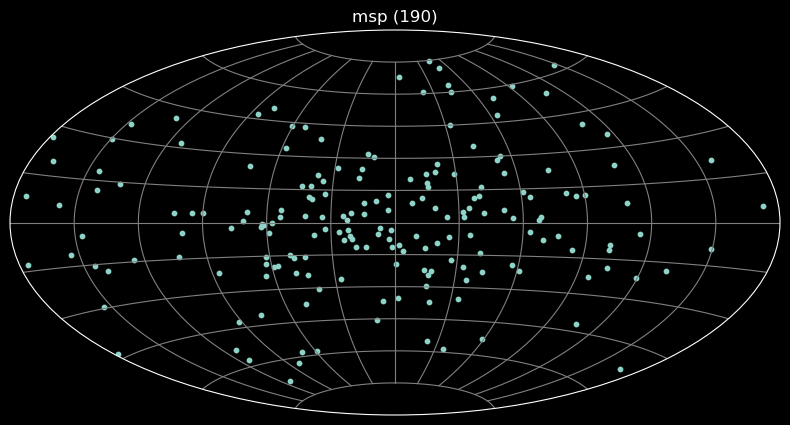

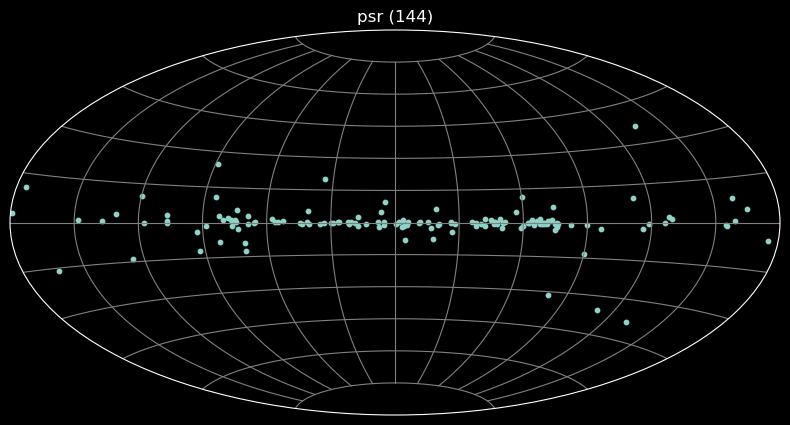

In [3]:
grp = df.groupby('association')
for n, dfx in grp:
    if n in 'blazar psr msp'.split(): 
        sk = AITfigure()
        sk.scatter(SkyCoord(dfx.glon, dfx.glat, unit='deg', frame='galactic'), s=10,)
        sk.title(n+ f' ({len(dfx)})')
    plt.show()

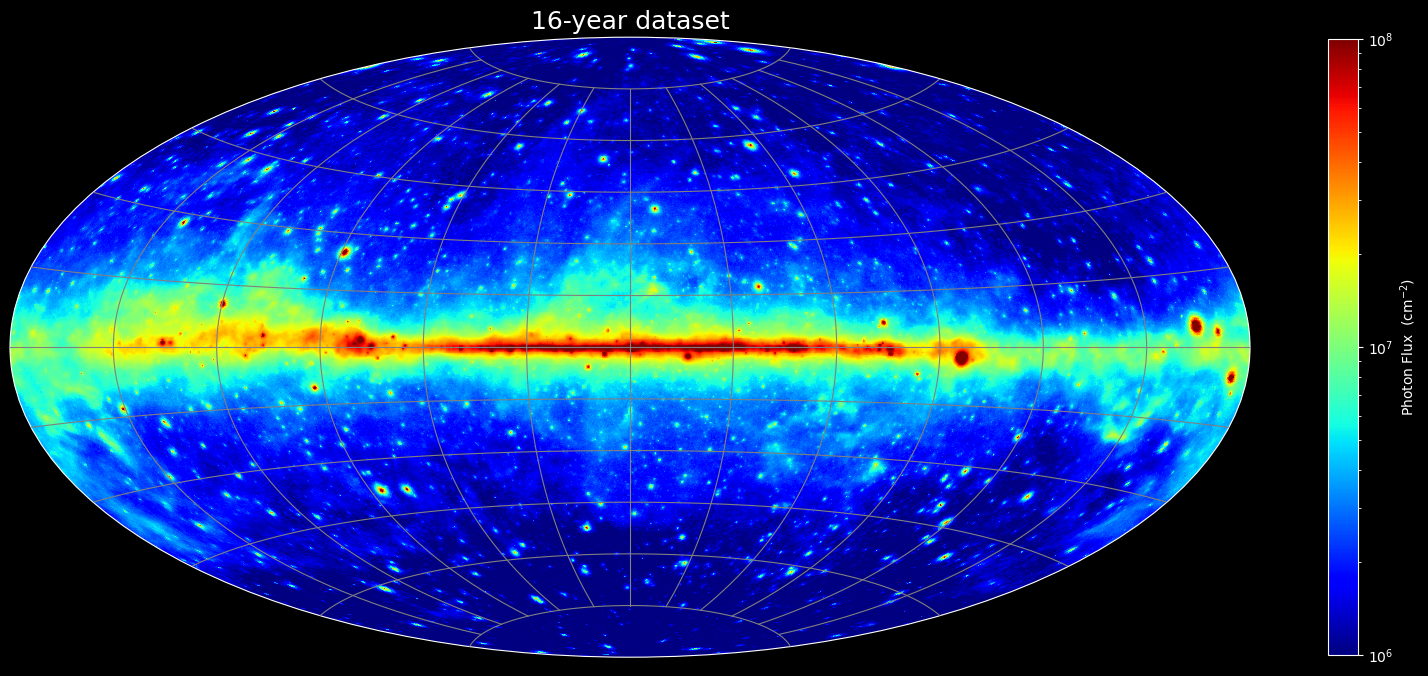

In [6]:
from astropy.io import fits
with fits.open('files/hptables_kde_512_16.fits') as hdus:
    hparray = hdus[1].data['kde'] # Get the KDE column
from matplotlib.colors import LogNorm
(AITfigure(figsize=(20,10))
  .healpix_fill(hparray, pixelsize=0.25, cmap='jet', norm=LogNorm(vmin=1e6, vmax=1e8))
  .colorbar(shrink=0.8, label=r'Photon Flux  ($\mathrm{cm}^{-2}$)')
  .title('16-year dataset', fontsize=18)
)
plt.show()